# Uber Trip Analysis & Demand Prediction

**Objective:** To analyze aggregated daily Uber trip statistics from January and February 2015 to identify patterns and build a predictive machine learning model for trip demand. 

As a Data Analyst, predicting ride demand is crucial for optimizing fleet deployment. In this project, we will map the raw TLC dispatch base codes to their actual company names (e.g., Unter, Grun), engineer time-based features, and train **multiple machine learning models** to automatically select the best algorithm for forecasting the total number of trips.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

### 1. Data Preprocessing
First, we load the Freedom of Information Law (FOIL) dataset. Machine learning models require clean, structured data, so we will convert the raw date strings into proper datetime objects. We also map the alphanumeric dispatching base numbers (like B02512) to theira actual company names to make our analysis readable for business stakeholders.

In [4]:
# Load dataset
data = pd.read_csv('Uber-Jan-Feb-FOIL.csv')
data['date'] = pd.to_datetime(data['date'])

# Map the base codes to company names
base_mapping = {
    'B02512': 'Unter', 'B02598': 'Hinter', 'B02617': 'Weiter', 
    'B02682': 'Schmecken', 'B02764': 'Danach-NY', 'B02765': 'Grun'
}
data['Base_Name'] = data['dispatching_base_number'].map(base_mapping)

print(f"Dataset loaded successfully. Shape: {data.shape}")
display(data.head(3))

Dataset loaded successfully. Shape: (354, 5)


,dispatching_base_number,date,active_vehicles,trips,Base_Name
0,B02512,2015-01-01,190,1132,Unter
1,B02765,2015-01-01,225,1765,Grun
2,B02764,2015-01-01,3427,29421,Danach-NY


### 2. Exploratory Data Analysis (EDA)
Before building a predictive model, we must understand the underlying demand patterns in our data. 

In this section, we visualize:
1. **Average Trips by Day of the Week:** To identify which days experience peak ride demand.
2. **Trips per Dispatch Base:** To see which specific Uber base handles the highest volume.
3. **Active Vehicles vs. Total Trips:** To verify the linear correlation between fleet size and completed rides.

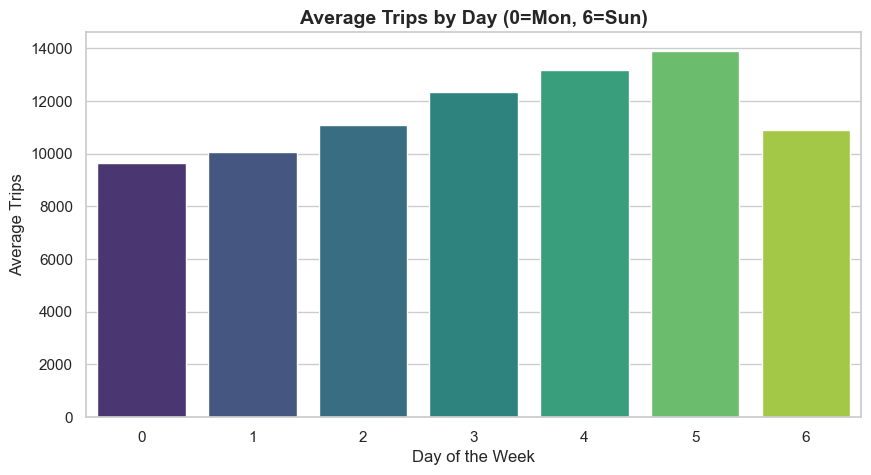

In [5]:
# 1. Average Trips by Day of Week
plt.figure(figsize=(10, 5))
data['DayOfWeek'] = data['date'].dt.dayofweek
sns.barplot(x='DayOfWeek', y='trips', data=data, ci=None, palette='viridis')
plt.title('Average Trips by Day (0=Mon, 6=Sun)', weight='bold', fontsize=14)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Average Trips', fontsize=12)
plt.show()

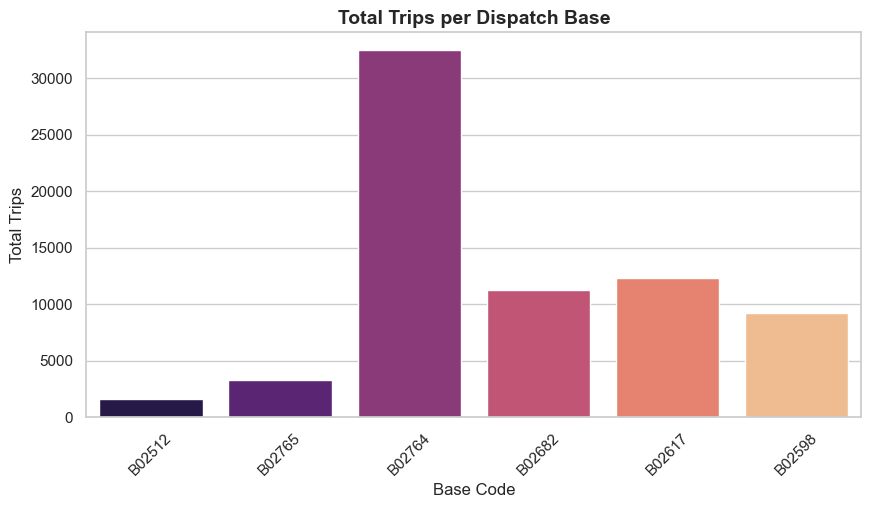

In [6]:
# 2. Total Trips per Dispatch Base
plt.figure(figsize=(10, 5))
sns.barplot(x='dispatching_base_number', y='trips', data=data, ci=None, palette='magma')
plt.title('Total Trips per Dispatch Base', weight='bold', fontsize=14)
plt.xlabel('Base Code', fontsize=12)
plt.ylabel('Total Trips', fontsize=12)
plt.xticks(rotation=45)
plt.show()


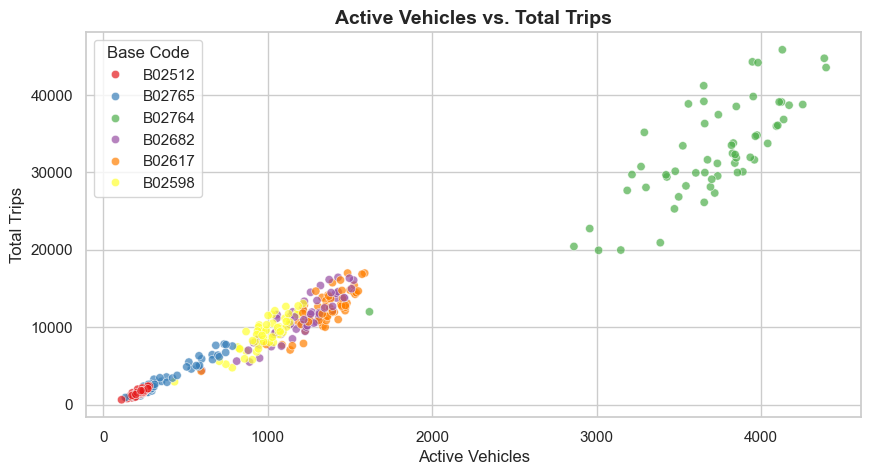

In [7]:
# 3. Active Vehicles vs Trips
plt.figure(figsize=(10, 5))
sns.scatterplot(x='active_vehicles', y='trips', data=data, hue='dispatching_base_number', palette='Set1', alpha=0.7)
plt.title('Active Vehicles vs. Total Trips', weight='bold', fontsize=14)
plt.xlabel('Active Vehicles', fontsize=12)
plt.ylabel('Total Trips', fontsize=12)
plt.legend(title='Base Code')
plt.show()

### 3. Feature Engineering
Our predictive algorithm cannot process raw dates or text strings. We must transform our data:
* **Time Features:** We extract the exact `Day` and `Month` from our datetime column.
* **One-Hot Encoding:** We convert our categorical `Base_Name` column into multiple binary (0 or 1) columns using `pd.get_dummies()`. This allows the mathematical model to understand which company base is handling the trips.

In [8]:
# Extract temporal features
data['Day'] = data['date'].dt.day
data['Month'] = data['date'].dt.month


In [9]:
# One-Hot Encode categorical variable
data_encoded = pd.get_dummies(data, columns=['Base_Name'], drop_first=True)

X = data_encoded.drop(columns=['date', 'dispatching_base_number', 'trips'])
y = data_encoded['trips']

print("Features Prepared for Modeling:")
print(X.columns.tolist())

Features Prepared for Modeling:
['active_vehicles', 'DayOfWeek', 'Day', 'Month', 'Base_Name_Grun', 'Base_Name_Hinter', 'Base_Name_Schmecken', 'Base_Name_Unter', 'Base_Name_Weiter']


### 4. Automated Model Training & Comparison
We split our processed dataset into a Training set (70%) and a Testing set (30%). 

Instead of relying on just one algorithm, we will train a suite of models (**Decision Tree, Random Forest, Gradient Boosting, and XGBoost**). We will evaluate them using **Mean Absolute Error (MAE)** and automatically select the one with the lowest error rate to act as our final production model.

In [10]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [11]:

# Define the models to test
models_to_test = {
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

trained_models = {}
model_errors = {}
model_predictions = {}

# Loop through each model: Train, Predict, and Score
for name, model in models_to_test.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    
    y_pred = model.predict(X_test)
    model_predictions[name] = y_pred
    
    # Calculate Mean Absolute Error
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    model_errors[name] = mae
    
    print(f"{name:<20} | MAE: {mae:.2f} | R2 Score: {r2:.4f}")



Decision Tree        | MAE: 1344.22 | R2 Score: 0.9598
Random Forest        | MAE: 826.74 | R2 Score: 0.9868
Gradient Boosting    | MAE: 723.51 | R2 Score: 0.9897
XGBoost              | MAE: 834.11 | R2 Score: 0.9839


In [13]:
# Automatically identify the best model (Lowest MAE)
best_model_name = min(model_errors, key=model_errors.get)
best_error_rate = model_errors[best_model_name]

# Set the best model as our FINAL model
final_model = trained_models[best_model_name]
final_predictions = model_predictions[best_model_name]

print(f"BEST MODEL AUTOMATICALLY SELECTED: {best_model_name}")
print(f"Lowest Error Rate (MAE): {best_error_rate:.2f}")


BEST MODEL AUTOMATICALLY SELECTED: Gradient Boosting
Lowest Error Rate (MAE): 723.51


### 5. Visualization: Actual vs Predicted Trips
To conclude our analysis, we plot our **Best Model's** predicted trip counts directly against the actual historical trip counts. The closer our predictions align with the true data points, the more accurate our algorithm is at forecasting Uber demand.

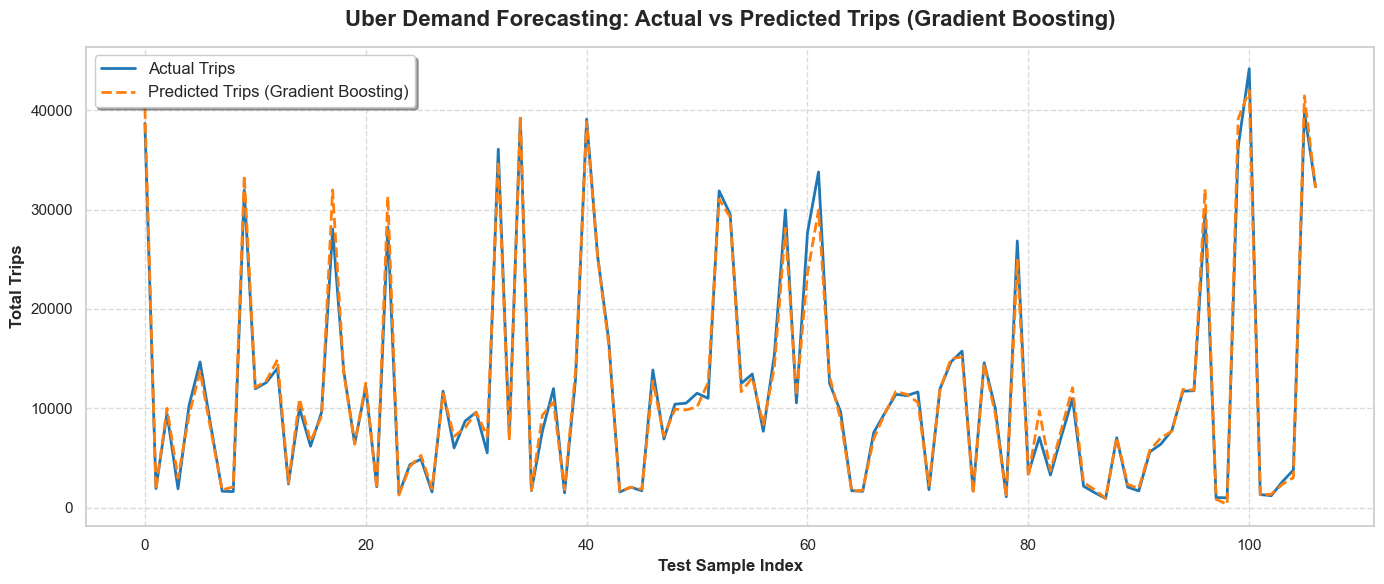

In [ ]:
plt.figure(figsize=(14, 6))

# We reset index so we can plot it cleanly
y_test_plot = y_test.reset_index(drop=True)

# Plot Actual vs Predicted 
sns.lineplot(data=y_test_plot, label='Actual Trips', color='#1f77b4', linewidth=2)
sns.lineplot(data=final_predictions, label=f'Predicted Trips ({best_model_name})', color='#ff7f0e', linestyle='--', linewidth=2)

plt.title(f'Uber Demand Forecasting: Actual vs Predicted Trips ({best_model_name})', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Test Sample Index', fontsize=12, fontweight='bold')
plt.ylabel('Total Trips', fontsize=12, fontweight='bold')
plt.legend(loc='upper left', fontsize=12, frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
print("--- CUSTOM SCENARIO FORECAST ---")

# Grab a sample from the test set to simulate future input
sample_scenario = X_test.iloc[[0]].copy()

# Use the dynamically selected final model
predicted_demand = final_model.predict(sample_scenario)

print(f"Model In Use    : {best_model_name}")
print(f"Active Vehicles : {sample_scenario['active_vehicles'].values[0]}")
print(f"Day of Week     : {sample_scenario['DayOfWeek'].values[0]} (0=Mon, 6=Sun)")
print(f"Month           : {sample_scenario['Month'].values[0]}")
print("-" * 32)
print(f"PREDICTED TRIPS : {int(predicted_demand[0])} trips")

--- CUSTOM SCENARIO FORECAST ---
Model In Use    : Gradient Boosting
Active Vehicles : 4170
Day of Week     : 4 (0=Mon, 6=Sun)
Month           : 2
--------------------------------
PREDICTED TRIPS : 40190 trips
